# Stock Market Analysis and Prediction

This notebook analyzes stock market data using Python, focusing on:
- Data collection using yfinance
- Technical analysis
- News sentiment analysis
- Machine learning predictions

## Required Libraries

Install Packages

In [4]:
import pandas as pd
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
%pip install yfinance
import yfinance as yf
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


## Data Analysis and Machine Learning Libraries
Importing essential libraries for data processing, natural language processing, and machine learning.

## Stock Market Data Collection
Installing and using yfinance to fetch real-time stock market data

## Testing a Stock Plot

C:\Users\Nik\AppData\Local\Temp\ipykernel_5028\3473104.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed



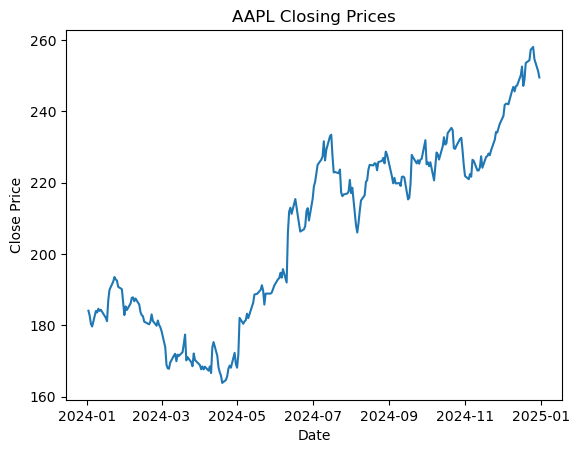

In [6]:
ticker = "AAPL"
data = yf.download(ticker, start="2024-01-01", end="2025-01-01")

plt.plot(data['Close'])
plt.title(f"{ticker} Closing Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

## Testing to Get Headlines 

In [ ]:
# Get technology sector tickers

# Define some major tech companies
tech_tickers = ["AAPL", "MSFT", "GOOGL", "META", "NVDA"]

# Get news for tech companies
for ticker in tech_tickers:
    stock = yf.Ticker(ticker)
    print(f"\nNews for {ticker}:")
    # Get the latest 3 news items for each company
    news = stock.news
    if news:
        for i, item in enumerate(news[:3], 1):
            # Print all available keys for debugging
            print(f"\n{i}. Headlines available fields:", item.keys())
            # Print the news details using available fields
            if 'publisher' in item:
                print(f"Publisher: {item['publisher']}")
            if 'headline' in item:
                print(f"Headline: {item['headline']}")
            elif 'title' in item:
                print(f"Title: {item['title']}")
            if 'link' in item:
                print(f"Link: {item['link']}")
            print()


News for AAPL:

1. Headlines available fields: dict_keys(['id', 'content'])


2. Headlines available fields: dict_keys(['id', 'content'])


3. Headlines available fields: dict_keys(['id', 'content'])


News for MSFT:

1. Headlines available fields: dict_keys(['id', 'content'])


2. Headlines available fields: dict_keys(['id', 'content'])


3. Headlines available fields: dict_keys(['id', 'content'])


News for GOOGL:

1. Headlines available fields: dict_keys(['id', 'content'])


2. Headlines available fields: dict_keys(['id', 'content'])


3. Headlines available fields: dict_keys(['id', 'content'])


News for META:

1. Headlines available fields: dict_keys(['id', 'content'])


2. Headlines available fields: dict_keys(['id', 'content'])


3. Headlines available fields: dict_keys(['id', 'content'])


News for GOOGL:

1. Headlines available fields: dict_keys(['id', 'content'])


2. Headlines available fields: dict_keys(['id', 'content'])


3. Headlines available fields: dict_keys(['id', '

## Market News Analysis
Fetching and analyzing news for major technology companies

In [ ]:
yf.Market("Energy").summary()

Energy: Failed to parse market summary


TypeError: 'dict' object is not callable

In [ ]:
# Load historical stock data
stock_data = pd.read_csv('stock_data.csv')

## Data Processing and Feature Engineering
Loading historical data and preparing it for analysis

In [ ]:
# Load recent headlines and social media posts
headlines = pd.read_csv('headlines.csv')
social_media_posts = pd.read_csv('social_media_posts.csv')

In [ ]:
# Preprocess text data
nltk.download('punkt')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(tokens)

headlines['text'] = headlines['text'].apply(preprocess_text)
social_media_posts['text'] = social_media_posts['text'].apply(preprocess_text)


In [ ]:
# Extract features from text data
vectorizer = TfidfVectorizer(stop_words='english')
X_headlines = vectorizer.fit_transform(headlines['text'])
X_social_media_posts = vectorizer.transform(social_media_posts['text'])

In [ ]:
# Combine features
X = np.concatenate((X_headlines, X_social_media_posts), axis=1)


In [ ]:
# Define target variable
y = stock_data['target']

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training and Evaluation
Splitting the data and training the machine learning model

In [ ]:
# Train model
model = LogisticRegression()
model.fit(X_train, y_train)


In [ ]:
# Evaluate model
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

In [ ]:
# Implement feedback mechanism
def update_model(new_data):
    # Update model weights or retrain model with new data
    pass

## Model Updates and Predictions
Implementing feedback mechanism and making new predictions

In [ ]:
# Example usage
new_headlines = pd.read_csv('new_headlines.csv')
new_social_media_posts = pd.read_csv('new_social_media_posts.csv')
new_X = np.concatenate((vectorizer.transform(new_headlines['text']), vectorizer.transform(new_social_media_posts['text'])), axis=1)
new_y = model.predict(new_X)
print('New predictions:', new_y)
update_model(new_data=new_X, new_y=new_y)